In [1]:
import numpy as np

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [2]:
def cross_entropy_loss(y_true, y_pred):
    m = y_true.shape[0]

    y_pred = np.clip(y_pred, 1e-10, 1.0)

    return -np.sum(y_true * np.log(y_pred)) / m

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")

X = df.drop("price_range", axis=1).values
y = df["price_range"].values

X = (X - X.mean(axis=0)) / X.std(axis=0)

num_classes = len(np.unique(y))
y_onehot = np.eye(num_classes)[y]

X = np.hstack((np.ones((X.shape[0], 1)), X))

np.random.seed(42)
W = np.random.randn(X.shape[1], num_classes) * 0.01

learning_rate = 0.01
epochs = 100
loss_history = []

for epoch in range(epochs):
    total_loss = 0

    for i in range(X.shape[0]):
        xi = X[i:i+1]
        yi = y_onehot[i:i+1]

        logits = np.dot(xi, W)
        y_pred = softmax(logits)

        loss = cross_entropy_loss(yi, y_pred)
        total_loss += loss

        grad = np.dot(xi.T, (y_pred - yi))

        W -= learning_rate * grad

    avg_loss = total_loss / X.shape[0]
    loss_history.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

Epoch 0, Loss: 0.8547
Epoch 10, Loss: 0.3096
Epoch 20, Loss: 0.2392
Epoch 30, Loss: 0.2053
Epoch 40, Loss: 0.1844
Epoch 50, Loss: 0.1698
Epoch 60, Loss: 0.1588
Epoch 70, Loss: 0.1502
Epoch 80, Loss: 0.1432
Epoch 90, Loss: 0.1374


In [5]:
X_vis = df[["battery_power", "ram"]].values
y_vis = df["price_range"].values

X_vis = (X_vis - X_vis.mean(axis=0)) / X_vis.std(axis=0)
X_vis_bias = np.hstack((np.ones((X_vis.shape[0], 1)), X_vis))

W_vis = np.random.randn(3, num_classes) * 0.01

for epoch in range(100):
    for i in range(X_vis_bias.shape[0]):
        xi = X_vis_bias[i:i+1]
        yi = np.eye(num_classes)[y_vis[i:i+1]]

        logits = np.dot(xi, W_vis)
        y_pred = softmax(logits)

        grad = np.dot(xi.T, (y_pred - yi))
        W_vis -= 0.01 * grad

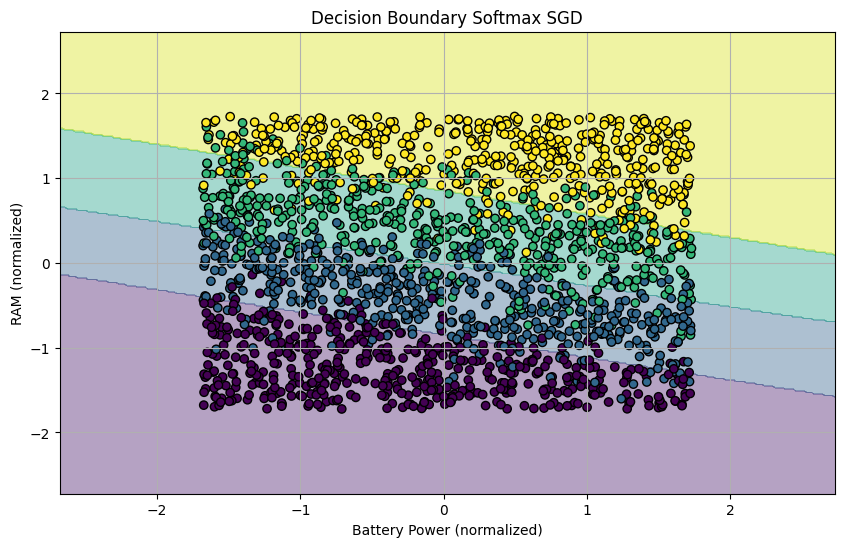

In [6]:
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_bias = np.hstack((np.ones((grid.shape[0], 1)), grid))

Z = np.dot(grid_bias, W_vis)
Z = np.argmax(softmax(Z), axis=1)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolors='k')
plt.title("Decision Boundary Softmax SGD")
plt.xlabel("Battery Power (normalized)")
plt.ylabel("RAM (normalized)")
plt.grid(True)
plt.show()